## **Definição do Problema de Negócio**

### 1.1. O Problema de Negócio

Nossa loja de e-commerce está em crescimento e gera um grande volume de dados de vendas. Porém, esses dados brutos não são utilizados de forma estratégica, dificultando o acesso a informações valiosas para o negócio.

As decisões atuais são baseadas em intuição, o que gera os seguintes desafios:

* **Gestão de Estoque Ineficiente:** Falta de visibilidade sobre produtos mais e menos vendidos, causando excesso ou falta de estoque.
* **Marketing com Baixo Retorno:** Campanhas genéricas por não sabermos quais categorias e regiões geram mais vendas.
* **Perda de Oportunidades Sazonais:** Ausência de análise temporal impede o aproveitamento de tendências e sazonalidades.
* **Expansão sem Direção:** Falta de dados para identificar mercados regionais mais promissores.

O problema central é a **falta de visibilidade sobre a performance do negócio**, impedindo decisões rápidas e baseadas em dados.

---

### 1.2. Objetivos do Projeto

O projeto tem como objetivo transformar dados brutos de vendas em **insights acionáveis**, respondendo às seguintes perguntas de negócio:

* **O que vender?** Identificar os produtos com melhor desempenho.
* **Onde focar?** Descobrir as categorias que mais geram receita.
* **Quando agir?** Analisar tendências, picos e sazonalidades ao longo do tempo.
* **Para onde expandir?** Identificar os mercados geográficos mais fortes.

---

### 1.3. Solução Proposta

A solução envolve a consolidação, limpeza e análise do histórico de vendas da plataforma. Utilizando ferramentas como **Python, Pandas, NumPy e Matplotlib**, será gerado um relatório visual e intuitivo para apoiar as áreas de gestão, marketing e operações.

---

### 1.4. Resultados Esperados e Benefícios de Negócio

Com a execução do projeto, espera-se alcançar:

* **Otimização de Estoque:** Redução de custos e melhor reposição com base nos produtos mais vendidos.
* **Marketing Mais Eficiente:** Campanhas segmentadas por categoria e região, aumentando o ROI.
* **Planejamento Estratégico:** Melhor previsão e preparação para períodos de alta e baixa demanda.
* **Decisões Orientadas por Dados:** Substituição da intuição por análises concretas, promovendo crescimento sustentável.


## **1. Importação das Bibliotecas**

In [1]:
# Instala o pacote watermark
!pip install -q -U watermark

In [2]:
# Importação da biblioteca para manipulação de dados em tabelas
import pandas as pd

# Importação da biblioteca NumPy para operações matemáticas e arrays
import numpy as np

# Importação da biblioteca Matplotlib para geração de gráficos
import matplotlib.pyplot as plt

# Importação da biblioteca Seaborn para visualização estatística de dados
import seaborn as sns

# Importação da biblioteca random para geração de números aleatórios
import random

# Importação das classes datetime e timedelta para manipulação de datas e intervalos de tempo
from datetime import datetime, timedelta

# Comando mágico do Jupyter Notebook que permite exibir gráficos diretamente no notebook
%matplotlib inline

In [3]:
%reload_ext watermark
%watermark -a "Data Science Academy"

Author: Data Science Academy



In [4]:
%watermark --iversions

matplotlib: 3.10.0
numpy     : 2.1.3
pandas    : 2.3.1
seaborn   : 0.13.2



In [5]:
# Para instalar uma versão específica de um pacote, podemos fazer assim (por exemplo):
!pip install -q pandas==2.3.1

## **2. Função Para Geração de Dados Fictícios**

In [6]:
def gera_dados_ficticios(num_registros = 600):

    """ Gera um Dataframe do Pandas com dados de vendas fictícios."""

    # Mensagem inicial indicando a quantidade de registros a serem gerados
    print(f"\nIniciando a geração de {num_registros} registros de vendas...")

    # Dicionário com produtos, suas categorias e preços
    produtos = {
        'Laptop Gamer': {'categoria': 'Eletrônicos', 'preco': 7500.00},
        'Mouse Vertical': {'categoria': 'Acessórios', 'preco': 250.00},
        'Teclado Mecânico': {'categoria': 'Acessórios', 'preco': 550.00},
        'Monitor Ultrawide': {'categoria': 'Eletrônicos', 'preco': 2800.00},
        'Cadeira Gamer': {'categoria': 'Móveis', 'preco': 1200.00},
        'Headset 7.1': {'categoria': 'Acessórios', 'preco': 800.00},
        'Placa de Vídeo': {'categoria': 'Hardware', 'preco': 4500.00},
        'SSD 1TB': {'categoria': 'Hardware', 'preco': 600.00}
    }

    # Cria uma lista apenas com os nomes dos produtos
    lista_produtos = list(produtos.keys())

    # Dicionário com cidades e seus respectivos estados
    cidades_estados = {
        'São Paulo': 'SP', 'Rio de Janeiro': 'RJ', 'Belo Horizonte': 'MG',
        'Porto Alegre': 'RS', 'Salvador': 'BA', 'Curitiba': 'PR', 'Fortaleza': 'CE'
    }

    # Cria uma lista apenas com os nomes das cidades
    lista_cidades = list(cidades_estados.keys())

    # Lista que armazenará os registros de vendas
    dados_vendas = []

    # Define a data inicial dos pedidos
    data_inicial = datetime(2026, 1, 1)

    # Loop para gerar os registros de vendas
    for i in range(num_registros):

        # Seleciona aleatoriamente um produto
        produto_nome = random.choice(lista_produtos)

        # Seleciona aleatoriamente uma cidade
        cidade = random.choice(lista_cidades)

        # Gera uma quantidade de produtos vendida entre 1 e 7
        quantidade = np.random.randint(1, 8)

        # Calcula a data do pedido a partir da data inicial
        data_pedido = data_inicial + timedelta(days = int(i/5), hours = random.randint(0, 23))

        # Se o produto for Mouse ou Teclado, aplica desconto aleatório de até 10%
        if produto_nome in ['Mouse Vertical', 'Teclado Mecânico']:
            preco_unitario = produtos[produto_nome]['preco'] * np.random.uniform(0.9, 1.0)
        else:
            preco_unitario = produtos[produto_nome]['preco']

        # Adiciona um registro de venda à lista
        dados_vendas.append({
            'ID_Pedido': 1000 + i,
            'Data_Pedido': data_pedido,
            'Nome_Produto': produto_nome,
            'Categoria': produtos[produto_nome]['categoria'],
            'Preco_Unitario': round(preco_unitario, 2),
            'Quantidade': quantidade,
            'ID_Cliente': np.random.randint(100, 150),
            'Cidade': cidade,
            'Estado': cidades_estados[cidade]
        })

    # Mensagem final indicando que a geração terminou
    print("Geração de dados concluída.\n")

    # Retorna os dados no formato de DataFrame
    return pd.DataFrame(dados_vendas)    

## **3. Gerar, Carregar e Explorar Dados**

In [7]:
# Gera os dados chamando a função da célula anterior
df_vendas = gera_dados_ficticios(500)


Iniciando a geração de 500 registros de vendas...
Geração de dados concluída.



In [8]:
# Exibe as 5 primeiras linhas do DataFrame
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
0,1000,2026-01-01 11:00:00,Monitor Ultrawide,Eletrônicos,2800.00,1,123,Rio de Janeiro,RJ
1,1001,2026-01-01 11:00:00,SSD 1TB,Hardware,600.00,2,131,Fortaleza,CE
2,1002,2026-01-01 17:00:00,Placa de Vídeo,Hardware,4500.00,3,133,Porto Alegre,RS
3,1003,2026-01-01 14:00:00,Mouse Vertical,Acessórios,241.14,2,141,Porto Alegre,RS
4,1004,2026-01-01 10:00:00,Mouse Vertical,Acessórios,236.89,3,129,Fortaleza,CE


In [9]:
# Exibe as 5 últimas linhas do DataFrame
df_vendas.tail()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
495,1495,2026-04-10 21:00:00,Monitor Ultrawide,Eletrônicos,2800.0,2,139,São Paulo,SP
496,1496,2026-04-10 13:00:00,SSD 1TB,Hardware,600.0,6,131,São Paulo,SP
497,1497,2026-04-10 16:00:00,Cadeira Gamer,Móveis,1200.0,4,104,São Paulo,SP
498,1498,2026-04-10 02:00:00,Monitor Ultrawide,Eletrônicos,2800.0,7,145,Rio de Janeiro,RJ
499,1499,2026-04-10 17:00:00,SSD 1TB,Hardware,600.0,7,123,Belo Horizonte,MG


In [10]:
# Exibe informações gerais sobre o DataFrame (tipos de dados, valores não nulos)
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       500 non-null    int64         
 1   Data_Pedido     500 non-null    datetime64[ns]
 2   Nome_Produto    500 non-null    object        
 3   Categoria       500 non-null    object        
 4   Preco_Unitario  500 non-null    float64       
 5   Quantidade      500 non-null    int64         
 6   ID_Cliente      500 non-null    int64         
 7   Cidade          500 non-null    object        
 8   Estado          500 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 35.3+ KB


In [11]:
# Resumo estatístico
df_vendas.describe()

,ID_Pedido,Data_Pedido,Preco_Unitario,Quantidade,ID_Cliente
count,500.000000,500,500.000000,500.00000,500.000000
mean,1249.500000,2026-02-19 23:33:57.600000,2309.564960,3.93600,125.408000
min,1000.000000,2026-01-01 10:00:00,225.810000,1.00000,100.000000
25%,1124.750000,2026-01-26 01:45:00,600.000000,2.00000,114.000000
50%,1249.500000,2026-02-19 23:00:00,1200.000000,4.00000,125.000000
75%,1374.250000,2026-03-16 21:00:00,4500.000000,6.00000,138.000000
max,1499.000000,2026-04-10 21:00:00,7500.000000,7.00000,149.000000
std,144.481833,NaN,2373.135525,1.97172,14.246665


In [12]:
# Tipos de dados
df_vendas.dtypes

ID_Pedido                  int64
Data_Pedido       datetime64[ns]
Nome_Produto              object
Categoria                 object
Preco_Unitario           float64
Quantidade                 int64
ID_Cliente                 int64
Cidade                    object
Estado                    object
dtype: object

## **4. Limpeza, Pré-Processamento e Engenharia de Atributos**

In [13]:
# Se a coluna 'Data_Pedido' não estiver como tipo datetime, precisamos fazer a conversão explícita
# A coluna pode ser usada para análise temporal
df_vendas['Data_Pedido'] = pd.to_datetime(df_vendas['Data_Pedido'])

In [14]:
# Engenharia de atributos
# Criando a coluna 'Faturamento' (preço x quantidade)
df_vendas['Faturamento'] = df_vendas['Preco_Unitario'] * df_vendas['Quantidade']

In [15]:
# Engenharia de atributos
# Usando uma função lambda para criar uma coluna de status de entrega
df_vendas['Status_Entrega'] = df_vendas['Estado'].apply(lambda estado: 'Rápida' if estado in ['SP', 'RJ', 'MG'] else 'Normal')

In [16]:
# Exibe informações gerais sobre o DataFrame (tipos de dados, valores não nulos)
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       500 non-null    int64         
 1   Data_Pedido     500 non-null    datetime64[ns]
 2   Nome_Produto    500 non-null    object        
 3   Categoria       500 non-null    object        
 4   Preco_Unitario  500 non-null    float64       
 5   Quantidade      500 non-null    int64         
 6   ID_Cliente      500 non-null    int64         
 7   Cidade          500 non-null    object        
 8   Estado          500 non-null    object        
 9   Faturamento     500 non-null    float64       
 10  Status_Entrega  500 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 43.1+ KB


In [17]:
# Exibe as 5 primeiras linhas novamente para ver as novas colunas
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega
0,1000,2026-01-01 11:00:00,Monitor Ultrawide,Eletrônicos,2800.00,1,123,Rio de Janeiro,RJ,2800.00,Rápida
1,1001,2026-01-01 11:00:00,SSD 1TB,Hardware,600.00,2,131,Fortaleza,CE,1200.00,Normal
2,1002,2026-01-01 17:00:00,Placa de Vídeo,Hardware,4500.00,3,133,Porto Alegre,RS,13500.00,Normal
3,1003,2026-01-01 14:00:00,Mouse Vertical,Acessórios,241.14,2,141,Porto Alegre,RS,482.28,Normal
4,1004,2026-01-01 10:00:00,Mouse Vertical,Acessórios,236.89,3,129,Fortaleza,CE,710.67,Normal


## **5. Análise 1 - Top 10 Produtos Mais Vendidos**

In [18]:
# Agrupa por nome do produto, soma a quantidade e ordena para encontrar os mais vendidos
top_10_produtos = df_vendas.groupby('Nome_Produto')['Quantidade'].sum().sort_values(ascending = False).head(10)

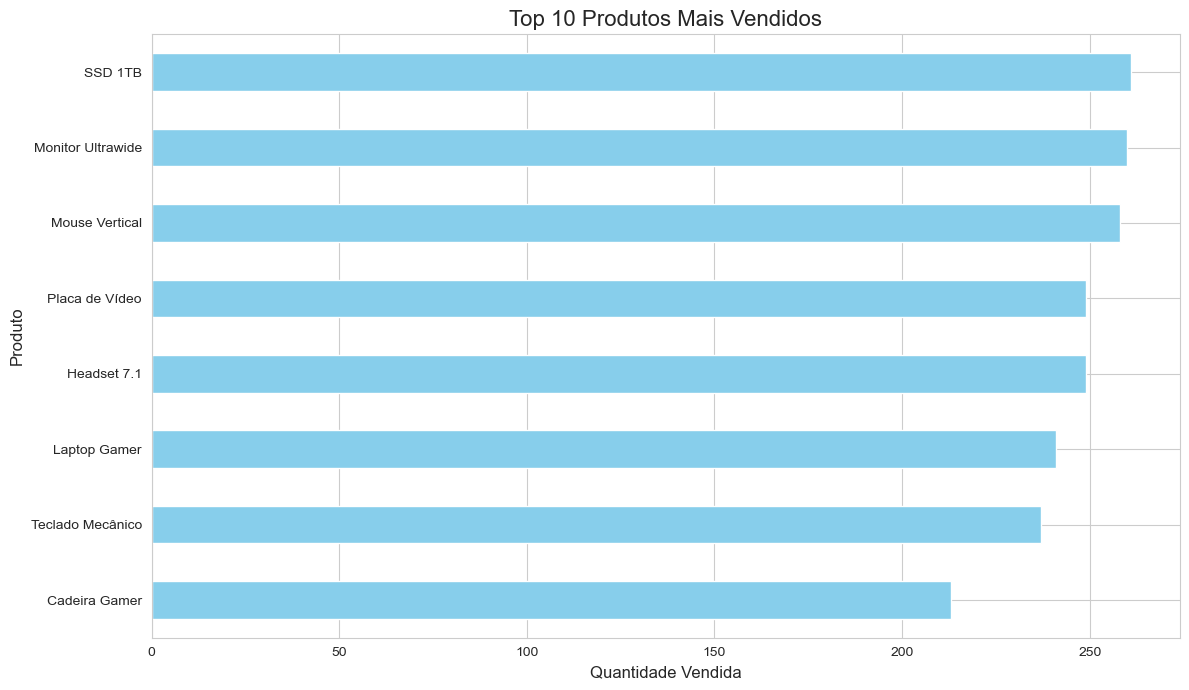

In [19]:
# Define um estilo para os gráficos
sns.set_style("whitegrid")

# Cria a figura e os eixos
plt.figure(figsize = (12, 7))

# Cria o gráfico de barras horizontais
top_10_produtos.sort_values(ascending = True).plot(kind = 'barh', color = 'skyblue')

# Adiciona títulos e labels
plt.title('Top 10 Produtos Mais Vendidos', fontsize = 16)
plt.xlabel('Quantidade Vendida', fontsize = 12)
plt.ylabel('Produto', fontsize = 12)

# Exibe o gráfico
plt.tight_layout()
plt.show()

## **6. Análise 2 - Faturamento Mensal**

In [20]:
# Cria uma coluna 'Mes' para facilitar o agrupamento mensal
df_vendas['Mes'] = df_vendas['Data_Pedido'].dt.to_period('M')

In [21]:
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mes
0,1000,2026-01-01 11:00:00,Monitor Ultrawide,Eletrônicos,2800.00,1,123,Rio de Janeiro,RJ,2800.00,Rápida,2026-01
1,1001,2026-01-01 11:00:00,SSD 1TB,Hardware,600.00,2,131,Fortaleza,CE,1200.00,Normal,2026-01
2,1002,2026-01-01 17:00:00,Placa de Vídeo,Hardware,4500.00,3,133,Porto Alegre,RS,13500.00,Normal,2026-01
3,1003,2026-01-01 14:00:00,Mouse Vertical,Acessórios,241.14,2,141,Porto Alegre,RS,482.28,Normal,2026-01
4,1004,2026-01-01 10:00:00,Mouse Vertical,Acessórios,236.89,3,129,Fortaleza,CE,710.67,Normal,2026-01


In [22]:
# Agrupa por mês e soma o faturamento
faturamento_mensal = df_vendas.groupby('Mes')['Faturamento'].sum()

In [23]:
# Converte o índice para string para facilitar a plotagem no gráfico
faturamento_mensal.index = faturamento_mensal.index.strftime('%Y-%m')

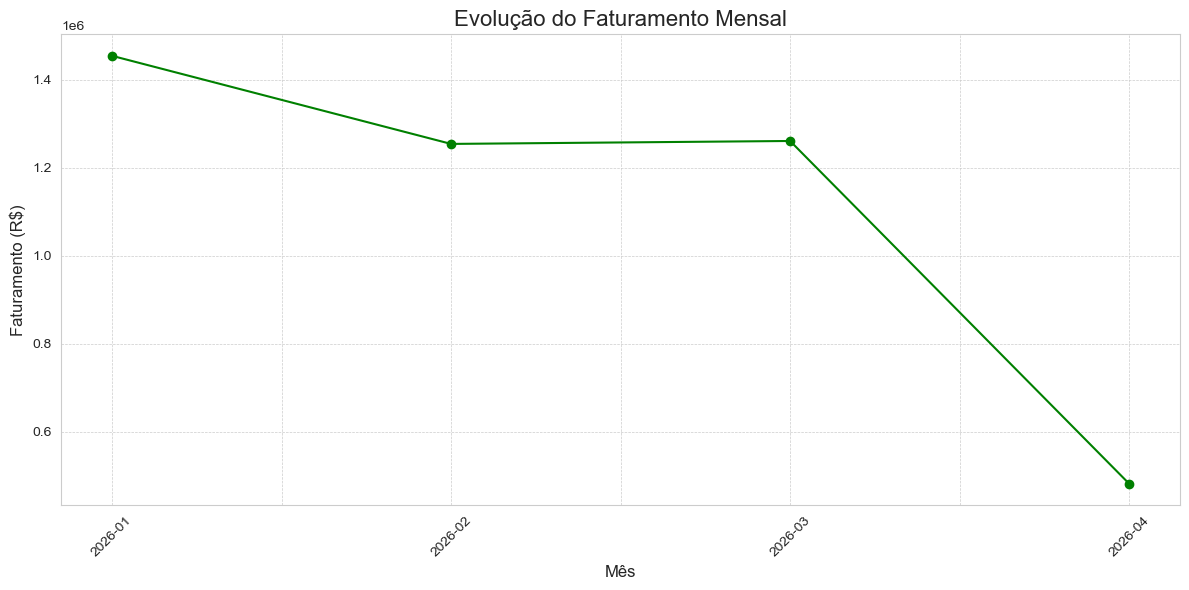

In [24]:
# Cria uma nova figura com tamanho de 12 por 6 polegadas
plt.figure(figsize = (12, 6))

# Plota os dados de faturamento mensal em formato de linha
faturamento_mensal.plot(kind = 'line', marker = 'o', linestyle = '-', color = 'green')

# Define o título do gráfico com fonte de tamanho 16
plt.title('Evolução do Faturamento Mensal', fontsize = 16)

# Define o rótulo do eixo X
plt.xlabel('Mês', fontsize = 12)

# Define o rótulo do eixo Y
plt.ylabel('Faturamento (R$)', fontsize = 12)

# Rotaciona os valores do eixo X em 45 graus para melhor visualização
plt.xticks(rotation = 45)

# Adiciona uma grade com estilo tracejado e linhas finas
plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)

# Ajusta automaticamente os elementos para evitar sobreposição
plt.tight_layout()

# Exibe o gráfico
plt.show()

## **7. Análise 3 - Vendas Por Estado**

In [25]:
# Agrupa por estado e soma o faturamento
vendas_estado = df_vendas.groupby('Estado')['Faturamento'].sum().sort_values(ascending = False)

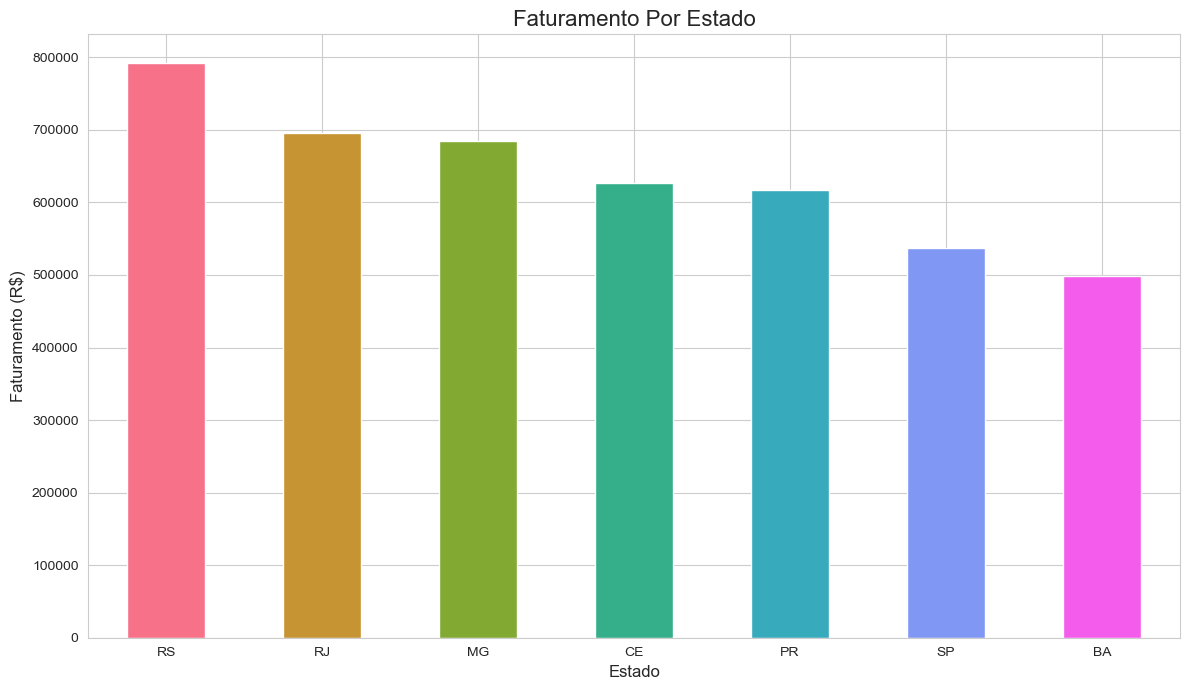

In [26]:
# Cria uma nova figura com tamanho de 12 por 7 polegadas
plt.figure(figsize = (12, 7))

# Plota os dados de faturamento por estado em formato de gráfico de barras
# Usando a paleta de cores "rocket" do Seaborn
vendas_estado.plot(kind = 'bar', color = sns.color_palette("husl", 7))

# Define o título do gráfico com fonte de tamanho 16
plt.title('Faturamento Por Estado', fontsize = 16)

# Define o rótulo do eixo X
plt.xlabel('Estado', fontsize = 12)

# Define o rótulo do eixo Y
plt.ylabel('Faturamento (R$)', fontsize = 12)

# Mantém os rótulos do eixo X na horizontal (sem rotação)
plt.xticks(rotation = 0)

# Ajusta automaticamente os elementos do gráfico para evitar sobreposição
plt.tight_layout()

# Exibe o gráfico
plt.show()

## **8. Análise 4 - Faturamento Por Categoria**

In [27]:
# Agrupa por categoria, soma o faturamento e formata como moeda para melhor leitura
faturamento_categoria = df_vendas.groupby('Categoria')['Faturamento'].sum().sort_values(ascending = False)

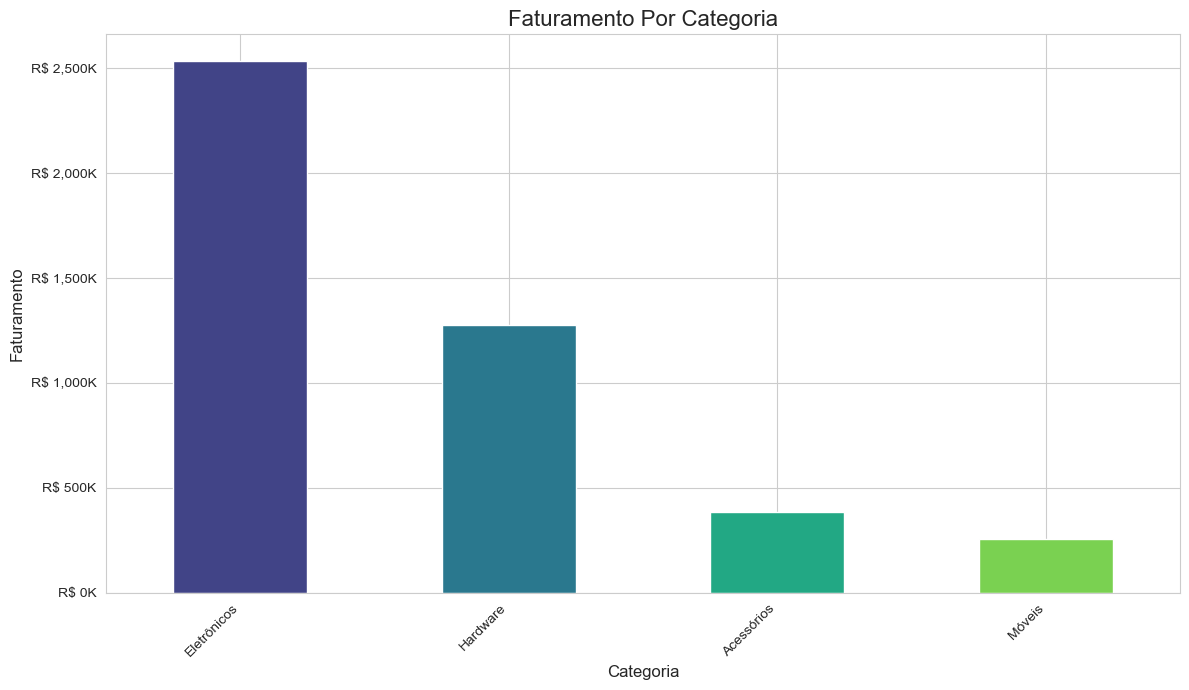

In [28]:
# Importa a função FuncFormatter para formatar os eixos
from matplotlib.ticker import FuncFormatter

# Ordena os dados para o gráfico ficar mais fácil de ler
faturamento_ordenado = faturamento_categoria.sort_values(ascending = False)

# Cria a Figura e os Eixos (ax) com plt.subplots()
# Isso nos dá mais controle sobre os elementos do gráfico.
fig, ax = plt.subplots(figsize = (12, 7))

# Cria uma função para formatar os números
# Esta função recebe um valor 'y' e o transforma em uma string no formato 'R$ XX K'
def formatador_milhares(y, pos):
    """Formata o valor em milhares (K) com o cifrão R$."""
    return f'R$ {y/1000:,.0f}K'

# Cria o objeto formatador
formatter = FuncFormatter(formatador_milhares)

# Aplica o formatador ao eixo Y (ax.yaxis)
ax.yaxis.set_major_formatter(formatter)

# Plota os dados usando o objeto 'ax'
faturamento_ordenado.plot(kind = 'bar', ax = ax, color = sns.color_palette("viridis", len(faturamento_ordenado)))

# Adiciona títulos e labels usando 'ax.set_...'
ax.set_title('Faturamento Por Categoria', fontsize = 16)
ax.set_xlabel('Categoria', fontsize = 12)
ax.set_ylabel('Faturamento', fontsize = 12)

# Ajusta a rotação dos rótulos do eixo X
plt.xticks(rotation = 45, ha = 'right')

# Garante que tudo fique bem ajustado na imagem final
plt.tight_layout()

# Exibe o gráfico
plt.show()